#Installing the Required Libraries

We'll installl the following libraries to get started with the project.

In [1]:
#Install required libraries
!pip install yfinance
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.2 MB/s  0:00:02 eta 0:00:010m
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [yfinance]/10 [yfinance]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


ModuleNotFoundError: No module named 'statsmodels'

# Cost of Equity Capital - Top Down Approach

**Top-down approach** estimates beta using historical regression of company returns on market returns:

1. We'll collect historical monthly returns for stock and market.
2. Run the regression:  
   $$ R_{\\text{stock}} = \\alpha + \\beta R_{\\text{market}} + \\epsilon $$
3. Then, we'll use this $\\beta$ in CAPM to estimate cost of equity.

$$
r_e = r_f + \\beta_{\\text{top-down}} \\left( r_m - r_f \\right)
$$


We have selected **Britannia Industries Limited (NSE: BRITANNIA)** from the **FMCG Industry** as the target company for this project. Thus, we will regress its monthly historical returns for the last 5 years against the Market Index, NIFTY50.


##Prices of BRITANNIA and NIFTY50

In [ ]:
#Download stock prices for the security monthly data last 5 years
britannia_df = yf.download('BRITANNIA.NS',
                      start='2020-04-02',
                      end='2025-04-02', auto_adjust=True,
                      progress=False, interval='1mo'
)
britannia_df.head()


Price,Close,High,Low,Open,Volume
Ticker,BRITANNIA.NS,BRITANNIA.NS,BRITANNIA.NS,BRITANNIA.NS,BRITANNIA.NS
Date,,,,,
2020-05-01,3052.108887,3086.569621,2589.755664,2859.615973,16995136
2020-06-01,3255.305908,3349.429531,2986.077851,3085.666472,20944030
2020-07-01,3453.851074,3622.225770,3172.428477,3256.390000,23262219
2020-08-01,3365.733887,3617.708844,3327.750158,3456.921785,12445299
2020-09-01,3505.526855,3591.177257,3267.311937,3447.242247,11655825


In [ ]:
#Download Market index closing prices
nifty_df = yf.download('^BSESN', start='2020-04-02',
                      end='2025-04-02', auto_adjust=True,
                      progress=False, interval='1mo',
)
nifty_df.head()


Price,Close,High,Low,Open,Volume
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
Date,,,,,
2020-05-01,32424.099609,32845.480469,29968.449219,32748.140625,544100
2020-06-01,34915.800781,35706.550781,32348.099609,32906.050781,541900
2020-07-01,37606.890625,38617.031250,34927.199219,35009.589844,442900
2020-08-01,38628.289062,40010.171875,36911.230469,37595.730469,381900
2020-09-01,38067.929688,39359.511719,36495.980469,38754.000000,309800


##Log Returns of BRITANNIA and NIFTY50

In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

Date
2020-05-01         NaN
2020-06-01    0.074038
2020-07-01    0.074248
2020-08-01    0.026798
2020-09-01   -0.014613
2020-10-01    0.039812
2020-11-01    0.108402
2020-12-01    0.078420
2021-01-01   -0.031172
2021-02-01    0.059024
2021-03-01    0.008299
2021-04-01   -0.014789
2021-05-01    0.062671
2021-06-01    0.010444
2021-07-01    0.001982
2021-08-01    0.090230
2021-09-01    0.026981
2021-10-01    0.003049
2021-11-01   -0.038537
2021-12-01    0.020621
2022-01-01   -0.004122
2022-02-01   -0.030930
2022-03-01    0.040440
2022-04-01   -0.026079
2022-05-01   -0.026540
2022-06-01   -0.046930
2022-07-01    0.082357
2022-08-01    0.033593
2022-09-01   -0.036086
2022-10-01    0.056198
2022-11-01    0.038004
2022-12-01   -0.036456
2023-01-01   -0.021445
2023-02-01   -0.009919
2023-03-01    0.000498
2023-04-01    0.035322
2023-05-01    0.024405
2023-06-01    0.032928
2023-07-01    0.027570
2023-08-01   -0.025828
2023-09-01    0.015261
2023-10-01   -0.030125
2023-11-01    0.047593
2023-1

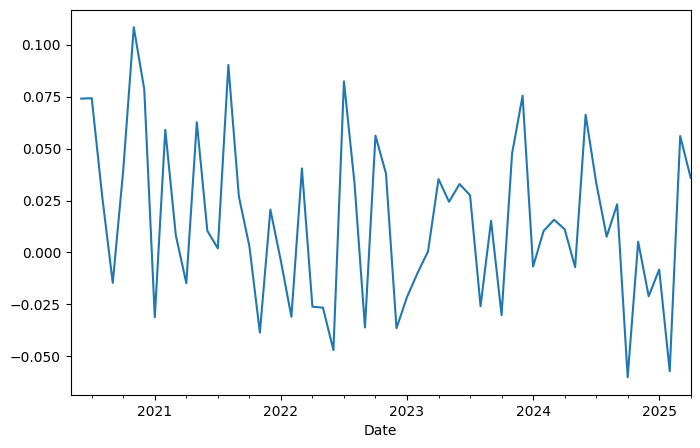

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

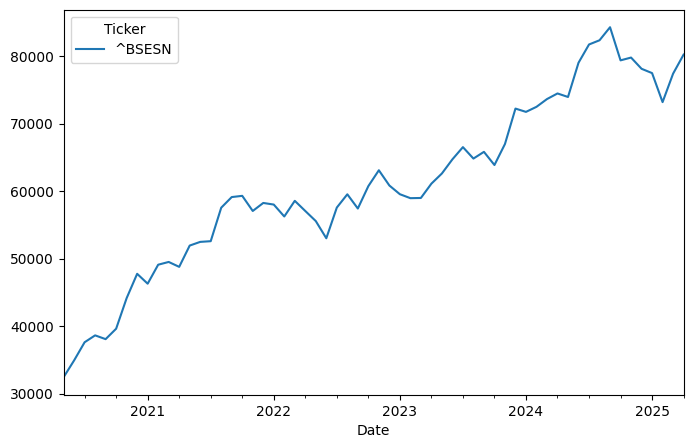

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

Price,Close,High,Low,Open,Volume,Return_NIFTY
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN,
Date,,,,,,
2020-06-01,34915.800781,35706.550781,32348.099609,32906.050781,541900,0.074038
2020-07-01,37606.890625,38617.031250,34927.199219,35009.589844,442900,0.074248
2020-08-01,38628.289062,40010.171875,36911.230469,37595.730469,381900,0.026798
2020-09-01,38067.929688,39359.511719,36495.980469,38754.000000,309800,-0.014613
2020-10-01,39614.070312,41048.050781,38410.199219,38410.199219,323000,0.039812


In [ ]:
print(britannia_df.head())
print(britannia_df.columns)

Price             Close         High          Low         Open       Volume  \
Ticker     BRITANNIA.NS BRITANNIA.NS BRITANNIA.NS BRITANNIA.NS BRITANNIA.NS   
Date                                                                          
2020-05-01  3052.108887  3086.569621  2589.755664  2859.615973     16995136   
2020-06-01  3255.305908  3349.429531  2986.077851  3085.666472     20944030   
2020-07-01  3453.851074  3622.225770  3172.428477  3256.390000     23262219   
2020-08-01  3365.733887  3617.708844  3327.750158  3456.921785     12445299   
2020-09-01  3505.526855  3591.177257  3267.311937  3447.242247     11655825   

Price      Return_BRITANNIA  
Ticker                       
Date                         
2020-05-01              NaN  
2020-06-01         0.064453  
2020-07-01         0.059204  
2020-08-01        -0.025844  
2020-09-01         0.040695  
MultiIndex([(           'Close', 'BRITANNIA.NS'),
            (            'High', 'BRITANNIA.NS'),
            (             '

In [ ]:
#Ensure 'Close' column is retrieved as a Series rather than a DataFrame
close_series = britannia_df['Close']
if isinstance(close_series, pd.DataFrame):
    close_series = close_series.squeeze()
close_series = pd.to_numeric(close_series, errors='coerce')

# Compute log returns
britannia_df['Return_BRITANNIA'] = np.log(close_series / close_series.shift(1))

print(britannia_df['Return_BRITANNIA'])


Date
2020-05-01         NaN
2020-06-01    0.064453
2020-07-01    0.059204
2020-08-01   -0.025844
2020-09-01    0.040695
2020-10-01   -0.089423
2020-11-01    0.046329
2020-12-01   -0.017077
2021-01-01   -0.021266
2021-02-01   -0.040021
2021-03-01    0.074812
2021-04-01   -0.049784
2021-05-01    0.016080
2021-06-01    0.060586
2021-07-01   -0.063997
2021-08-01    0.155035
2021-09-01   -0.012220
2021-10-01   -0.071692
2021-11-01   -0.036078
2021-12-01    0.016920
2022-01-01   -0.019801
2022-02-01   -0.030982
2022-03-01   -0.066668
2022-04-01    0.022466
2022-05-01    0.106509
2022-06-01   -0.051008
2022-07-01    0.135064
2022-08-01   -0.039923
2022-09-01    0.025111
2022-10-01   -0.020107
2022-11-01    0.146840
2022-12-01   -0.012653
2023-01-01    0.002354
2023-02-01    0.032841
2023-03-01   -0.031788
2023-04-01    0.052154
2023-05-01    0.039475
2023-06-01    0.075954
2023-07-01   -0.046981
2023-08-01   -0.070470
2023-09-01    0.015414
2023-10-01   -0.024690
2023-11-01    0.091916
2023-1

In [ ]:
britannia_df1 = britannia_df.dropna(axis=0)
britannia_df1.head()


Price,Close,High,Low,Open,Volume,Return_BRITANNIA
Ticker,BRITANNIA.NS,BRITANNIA.NS,BRITANNIA.NS,BRITANNIA.NS,BRITANNIA.NS,
Date,,,,,,
2020-06-01,3255.305908,3349.429531,2986.077851,3085.666472,20944030,0.064453
2020-07-01,3453.851074,3622.225770,3172.428477,3256.390000,23262219,0.059204
2020-08-01,3365.733887,3617.708844,3327.750158,3456.921785,12445299,-0.025844
2020-09-01,3505.526855,3591.177257,3267.311937,3447.242247,11655825,0.040695
2020-10-01,3205.658691,3581.025058,3121.438910,3525.693861,19698621,-0.089423


In [ ]:
britannia_df1_returns = britannia_df1['Return_BRITANNIA']
nifty_df1_returns = nifty_df1['Return_NIFTY']

returns_britannia = pd.merge(nifty_df1_returns, britannia_df1_returns, how='inner', on='Date')
print(returns_britannia.head())
returns_britannia.describe()


            Return_NIFTY  Return_BRITANNIA
Date                                      
2020-06-01      0.074038          0.064453
2020-07-01      0.074248          0.059204
2020-08-01      0.026798         -0.025844
2020-09-01     -0.014613          0.040695
2020-10-01      0.039812         -0.089423


,Return_NIFTY,Return_BRITANNIA
count,59.000000,59.000000
mean,0.015358,0.009572
std,0.039601,0.066333
min,-0.060019,-0.147576
25%,-0.014701,-0.036425
50%,0.011225,0.002354
75%,0.038908,0.059895
max,0.108402,0.155035


##Statistical Modelling of Return_BRITANNIA against Return_NIFTY

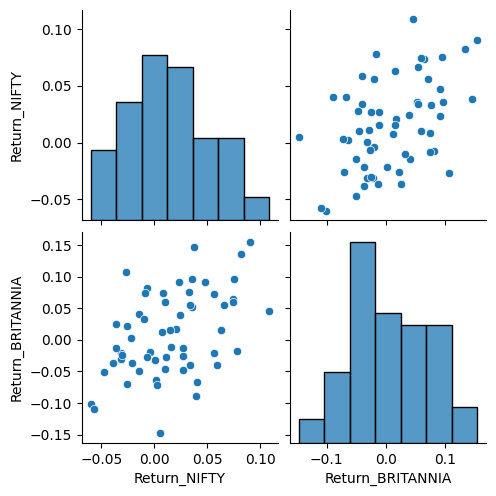

In [ ]:
sns.pairplot(returns_britannia)
plt.show()

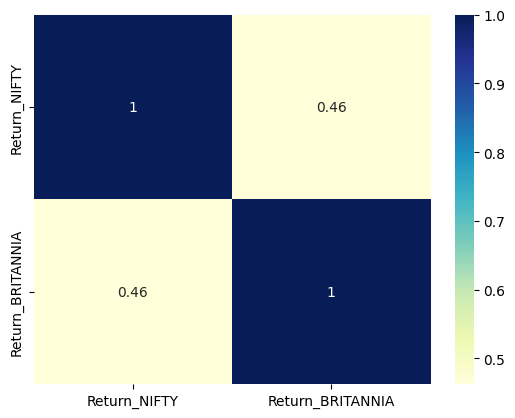

In [ ]:
sns.heatmap(returns_britannia.corr(), annot = True, cmap="YlGnBu")
plt.show()

##OLS Regression
OLS Ordinary Least Squares estimation minimizes the sum of squared errors

###Asumptions
* A linear relationship between the dependent and independent variables - The linear regression model is linear in parameters
* The independent variables are not highly correlated with each other - no multicollinearity
* The variance of the residuals is constant - no heteroskedasticity
* Random sampling of observation and no autocorrelation
* Expected Value of Error Term given the Independent Variable (Return_NIFTY, here) is 0
* Errors are Normally Distributed - Not necessary for uniasedness, but required for Testing

###Market Model Equation
$$
R_i = \alpha_i + \beta_i R_{M} + \epsilon_i
$$



* $R_i$ = Return of security $i$

* $\alpha_i$ = The return from the asset that is not related to the market’s return. This is "alpha" return from the security

* $\beta_i$ = Beta or the return from the security explained by the market index’s return

* $R_M$ = The market index’s return

* $\epsilon_i$ = Error term for past returns not explained by the regression equation

###OLS Regression of Return_BRITANNIA against Return_NIFTY

In [ ]:
x_britannia = returns_britannia['Return_NIFTY']
y_britannia = returns_britannia['Return_BRITANNIA']
x_sm_britannia = sm.add_constant(x_britannia)

#Regression - Market model
model_britannia = sm.OLS(y_britannia,x_sm_britannia)
results_britannia = model_britannia.fit()

#Regression result
results_britannia.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Return_BRITANNIA   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     15.50
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           0.000227
Time:                        15:29:19   Log-Likelihood:                 83.955
No. Observations:                  59   AIC:                            -163.9
Df Residuals:                      57   BIC:                            -159.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0023      0.008     -0.280      0.780      -0.019       0.014
Return_NIFTY     0.7746      0.197      3.938      0.000       0.381       1.169
==============================================================================
Omnibus:                        0.113   Durbin-Watson:                   2.323
Prob(Omnibus):                  0.945   Jarque-Bera (JB):                0.300
Skew:                          -0.057   Prob(JB):                        0.861
Kurtosis:                       2.670   Cond. No.                         25.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Levered Beta for Britannia = 0.7746 and is significant at 1%**


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Return_NIFTY      59 non-null     float64
 1   Return_BRITANNIA  59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_BRITANNIA'>

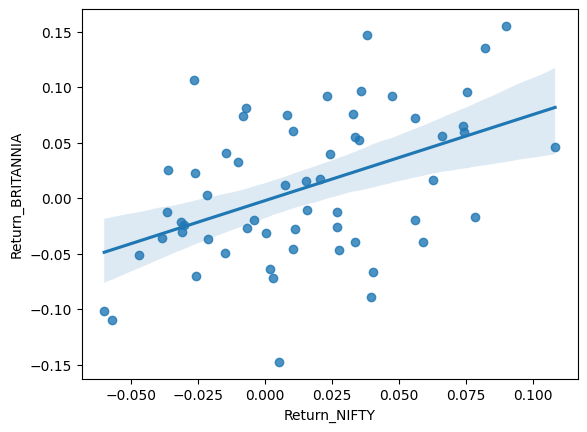

In [ ]:
#Regression - Security Characteristic line
returns_britannia.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_BRITANNIA', data = returns_britannia)

In [ ]:
print('resid', results_britannia.resid)

resid Date
2020-06-01    0.009430
2020-07-01    0.004017
2020-08-01   -0.044276
2020-09-01    0.054339
2020-10-01   -0.117936
2020-11-01   -0.035313
2020-12-01   -0.075496
2021-01-01    0.005205
2021-02-01   -0.083416
2021-03-01    0.070709
2021-04-01   -0.036004
2021-05-01   -0.030140
2021-06-01    0.054821
2021-07-01   -0.063207
2021-08-01    0.087469
2021-09-01   -0.030794
2021-10-01   -0.071730
2021-11-01   -0.003902
2021-12-01    0.003272
2022-01-01   -0.014283
2022-02-01   -0.004699
2022-03-01   -0.095667
2022-04-01    0.044991
2022-05-01    0.129392
2022-06-01   -0.012332
2022-07-01    0.073596
2022-08-01   -0.063620
2022-09-01    0.055387
2022-10-01   -0.061312
2022-11-01    0.119727
2022-12-01    0.017910
2023-01-01    0.021290
2023-02-01    0.042850
2023-03-01   -0.029849
2023-04-01    0.027119
2023-05-01    0.022896
2023-06-01    0.052773
2023-07-01   -0.066012
2023-08-01   -0.048139
2023-09-01    0.005918
2023-10-01    0.000969
2023-11-01    0.057376
2023-12-01    0.039271


count    5.900000e+01
mean     7.056502e-19
std      5.881497e-02
min     -1.492776e-01
25%     -4.013988e-02
50%      3.272101e-03
75%      4.392048e-02
max      1.293917e-01
dtype: float64

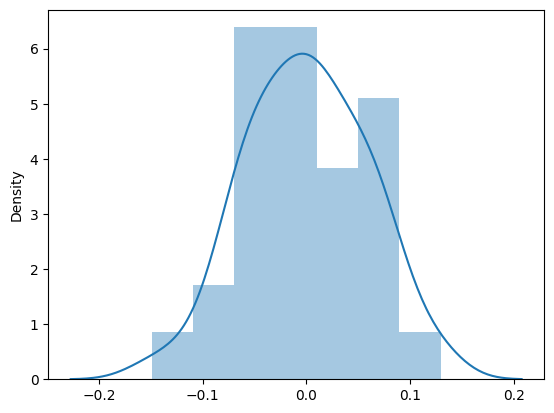

In [ ]:
#Histogram of residuals
sns.distplot(results_britannia.resid)
results_britannia.resid.describe()

###Statistical Significance of Levered Beta

In [ ]:
#Checking for Homoskedasticity of errors (Assumption requirement of linear regression)
#perform White's test
from statsmodels.stats.diagnostic import het_white
white_test = het_white(results_britannia.resid,  results_britannia.model.exog)

#define labels to use for output of White's test
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']

#print results of White's test
print(dict(zip(labels, white_test)))


{'Test Statistic': np.float64(1.2853289125185499), 'Test Statistic p-value': np.float64(0.525889346492795), 'F-Statistic': np.float64(0.623571249257723), 'F-Test p-value': np.float64(0.5397069038704747)}


The errors are **Homoskedastic** as per **White's Test**


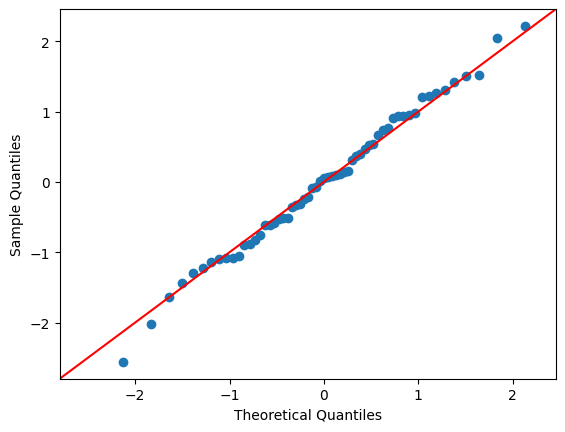

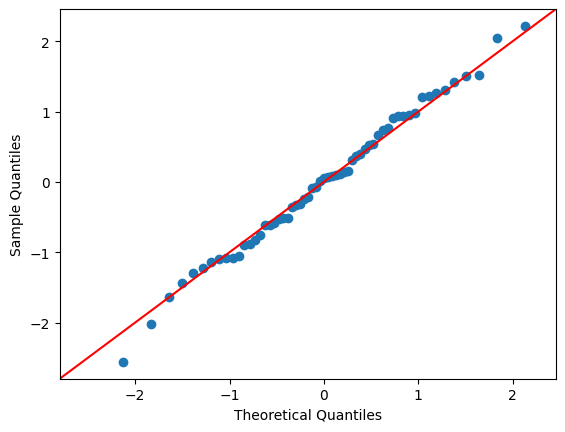

In [ ]:
#Testing for Normality of errors (Assumption requirement of linear regression)
sm.qqplot(results_britannia.resid,line='45',fit=True,dist=stats.norm)

In [ ]:
stats.normaltest(results_britannia.resid)

NormaltestResult(statistic=np.float64(0.11250382216942444), pvalue=np.float64(0.9453009741000932))

We can see that since we are plotting the data with the theoretical quantiles of a normal distribution, we are getting almost a straight line, though some points are not exactly on the line.
The D’Agostino’s K-squared test result suggests that the null hypothesis that the distribution is normal cannot be rejected at 1% significance level.

##CAPM Model

The CAPM (Capital Asset Pricing Model) is represented by the following equation:

$$
E(r_s) = r_f + \beta (E(r_m) - r_f)
$$

Where:
- E($r_s$) is the expected return on the investment (Cost of Equity).
- E($r_m$) is the expected return of the market.
- $r_f$ is the risk-free rate.
- $\beta$ is the beta, which measures the sensitivity of the investment's returns to market returns.

This equation helps in estimating the expected return on an investment based on its risk, market conditions, and the risk-free rate.

Cost of equity capital for **BRITANNIA** (Top-Down Approach)

In [ ]:
# Expected market return (annualized) using Top-Down approach
Expected_market_return_top_down = returns_britannia['Return_NIFTY'].mean() * 12
print("Expected Market Return:", Expected_market_return_top_down)

# Risk-free rate - Indian 10-year G-sec yield
Risk_free_rate = 0.06805642    # 6.805642%

# Cost of Equity using CAPM - Top-Down (levered beta from OLS on BRITANNIA)
beta_top_down = results_britannia.params['Return_NIFTY']
Cost_of_equity_top_down = Risk_free_rate + beta_top_down * (Expected_market_return_top_down - Risk_free_rate)

print("Levered Beta (Top-Down):", beta_top_down)
print("The Cost of Equity for Britannia Industries using the Top-Down approach:", Cost_of_equity_top_down)


Expected Market Return: 0.18430131363404412
Levered Beta (Top-Down): 0.7745895587387953
The Cost of Equity for Britannia Industries using the Top-Down approach: 0.15809850086563243


#Cost of Equity Capital - Bottom Up Approach

**Bottom-up approach** estimates beta by averaging industry betas and adjusting for capital structure.

1. First, we'll get the average unlevered beta from other FMCG players:
   $$
   \beta_u = \frac{\beta_l}{1 + \left(1 - T \right) \frac{D}{E}}
   $$
2. Re-lever the beta for Britannia Industries:
   $$
   \beta_l = \beta_u \left[ 1 + \left(1 - T \right) \frac{D}{E} \right]
   $$
3. Use this $\beta_l$ in CAPM to calculate Cost of Equity:

$$
r_e = r_f + \beta_{\text{bottom-up}} \left( r_m - r_f \right)
$$


We have selected the following companies, similar to **Britannia Industries**, from the FMCG Industry:
 * **Hindustan Unilever Limited (NSE: HINDUNILVR)**
 * **Nestlé India Limited (NSE: NESTLEIND)**
 * **Dabur India Limited (NSE: Dabur)**
 * **ITC Limited (NSE: ITC)**
 * **TATA Consumber Products Ltd (NSE: TATACONSUM)**

 We will calculate the Unlevered Beta for each company using the Regression formulae in the previous section, then relever it for Britannia Industries and calulate the Cost of Equity Capital

##Calculating Unlevered Beta for all the Companies

To calculate Unlevered Beta, we will use the equation:

$$
\text{Unlevered Beta} = \frac{\text{Levered Beta}}{1 + \left(\frac{D}{E} \times (1 - \text{Tax Rate})\right)}
$$

where D is Market Value of Debt, E is Market Value of Equity and Tax Rate is India's Corporate Tax Rate is 25.17% (including surcharge and cess)




###Hindustan Unilever Limited (NSE: HINDUNILVR)

####Prices of HINDUNILVR and NIFTY50


In [ ]:
#Download stock prices for the security monthly data last 5 years
hul_df = yf.download('HINDUNILVR.NS',
                      start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo'
)
hul_df.head()

Price,Close,High,Low,Open,Volume
Ticker,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS
Date,,,,,
2020-05-01,1859.090454,1983.475516,1718.710903,1983.475516,318486932
2020-06-01,1969.921021,1987.948465,1856.108426,1875.039503,77558947
2020-07-01,2010.568115,2138.031259,1933.326139,1986.094570,65932610
2020-08-01,1934.603271,2041.916209,1919.344457,2019.073940,36951713
2020-09-01,1889.740967,1996.414366,1827.427300,1964.389459,49268457


In [ ]:
#Download Market index closing prices
nifty_df = yf.download('^BSESN',start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo',
)
nifty_df.head()

Price,Close,High,Low,Open,Volume
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
Date,,,,,
2020-05-01,32424.099609,32845.480469,29968.449219,32748.140625,544100
2020-06-01,34915.800781,35706.550781,32348.099609,32906.050781,541900
2020-07-01,37606.890625,38617.031250,34927.199219,35009.589844,442900
2020-08-01,38628.289062,40010.171875,36911.230469,37595.730469,381900
2020-09-01,38067.929688,39359.511719,36495.980469,38754.000000,309800


####Log Returns of HINDUNILVR and NIFTY50


In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

Date
2020-05-01         NaN
2020-06-01    0.074038
2020-07-01    0.074248
2020-08-01    0.026798
2020-09-01   -0.014613
2020-10-01    0.039812
2020-11-01    0.108402
2020-12-01    0.078420
2021-01-01   -0.031172
2021-02-01    0.059024
2021-03-01    0.008299
2021-04-01   -0.014789
2021-05-01    0.062671
2021-06-01    0.010444
2021-07-01    0.001982
2021-08-01    0.090230
2021-09-01    0.026981
2021-10-01    0.003049
2021-11-01   -0.038537
2021-12-01    0.020621
2022-01-01   -0.004122
2022-02-01   -0.030930
2022-03-01    0.040440
2022-04-01   -0.026079
2022-05-01   -0.026540
2022-06-01   -0.046930
2022-07-01    0.082357
2022-08-01    0.033593
2022-09-01   -0.036086
2022-10-01    0.056198
2022-11-01    0.038004
2022-12-01   -0.036456
2023-01-01   -0.021445
2023-02-01   -0.009919
2023-03-01    0.000498
2023-04-01    0.035322
2023-05-01    0.024405
2023-06-01    0.032928
2023-07-01    0.027570
2023-08-01   -0.025828
2023-09-01    0.015261
2023-10-01   -0.030125
2023-11-01    0.047593
2023-1

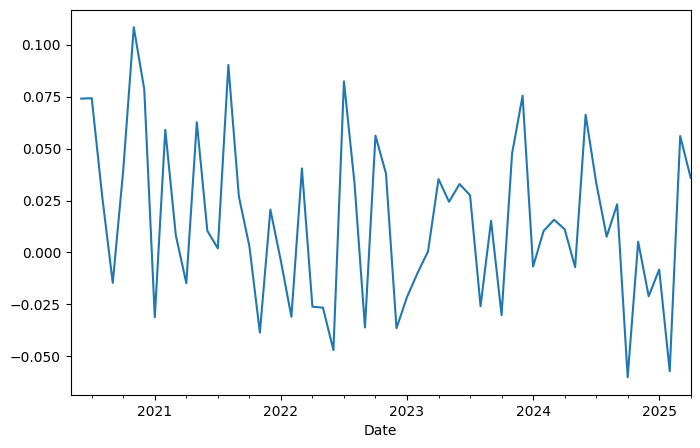

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

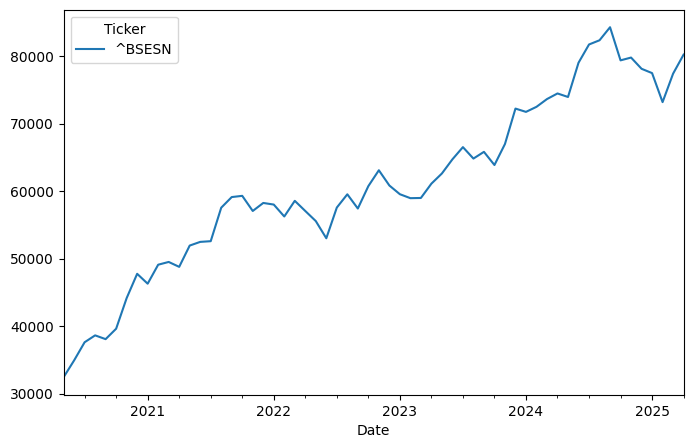

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

Price,Close,High,Low,Open,Volume,Return_NIFTY
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN,
Date,,,,,,
2020-06-01,34915.800781,35706.550781,32348.099609,32906.050781,541900,0.074038
2020-07-01,37606.890625,38617.031250,34927.199219,35009.589844,442900,0.074248
2020-08-01,38628.289062,40010.171875,36911.230469,37595.730469,381900,0.026798
2020-09-01,38067.929688,39359.511719,36495.980469,38754.000000,309800,-0.014613
2020-10-01,39614.070312,41048.050781,38410.199219,38410.199219,323000,0.039812


In [ ]:
#Ensure 'Close' column is retrieved as a Series rather than a Dataframe
close_series_hul = hul_df[('Close', 'HINDUNILVR.NS')]
close_series_hul = pd.to_numeric(close_series_hul, errors='coerce')

# Step 2: Compute log returns
hul_df[('Return_HINDUNILVR', '')] = np.log(close_series_hul / close_series_hul.shift(1))

# Step 3: Drop NaNs in return column
hul_df.dropna(subset=[('Return_HINDUNILVR', '')], inplace=True)

print(hul_df['Return_HINDUNILVR'])

Date
2020-06-01    0.057906
2020-07-01    0.020424
2020-08-01   -0.038515
2020-09-01   -0.023463
2020-10-01    0.001474
2020-11-01    0.038240
2020-12-01    0.113586
2021-01-01   -0.056461
2021-02-01   -0.060005
2021-03-01    0.131424
2021-04-01   -0.032499
2021-05-01   -0.005838
2021-06-01    0.054572
2021-07-01   -0.050251
2021-08-01    0.154855
2021-09-01   -0.008220
2021-10-01   -0.121308
2021-11-01   -0.025973
2021-12-01    0.018214
2022-01-01   -0.037295
2022-02-01   -0.045736
2022-03-01   -0.058513
2022-04-01    0.086993
2022-05-01    0.051623
2022-06-01   -0.053527
2022-07-01    0.176313
2022-08-01    0.008476
2022-09-01    0.013666
2022-10-01   -0.055568
2022-11-01    0.051071
2022-12-01   -0.040334
2023-01-01    0.006111
2023-02-01   -0.046103
2023-03-01    0.039718
2023-04-01   -0.041081
2023-05-01    0.082097
2023-06-01    0.003966
2023-07-01   -0.036672
2023-08-01   -0.022011
2023-09-01   -0.015874
2023-10-01    0.007435
2023-11-01    0.024477
2023-12-01    0.052771
2024-0

In [ ]:
hul_df1 = hul_df.dropna(axis=0)
hul_df1.head()

Price,Close,High,Low,Open,Volume,Return_HINDUNILVR
Ticker,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,
Date,,,,,,
2020-06-01,1969.921021,1987.948465,1856.108426,1875.039503,77558947,0.057906
2020-07-01,2010.568115,2138.031259,1933.326139,1986.094570,65932610,0.020424
2020-08-01,1934.603271,2041.916209,1919.344457,2019.073940,36951713,-0.038515
2020-09-01,1889.740967,1996.414366,1827.427300,1964.389459,49268457,-0.023463
2020-10-01,1892.527710,2017.886037,1889.512486,1909.613683,47771434,0.001474


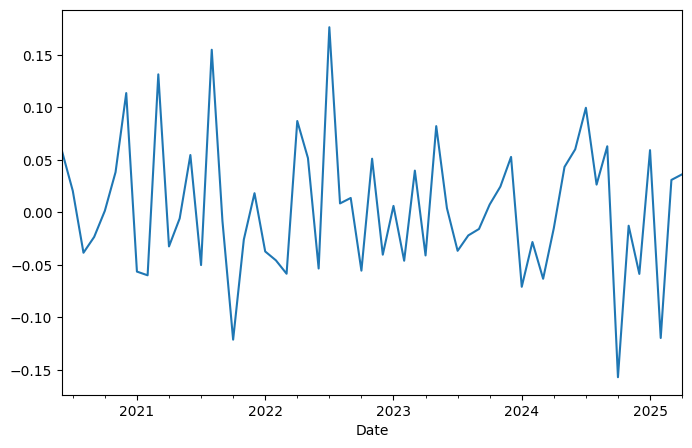

In [ ]:
hul_df['Return_HINDUNILVR'].plot(figsize=(8,5))
plt.show()

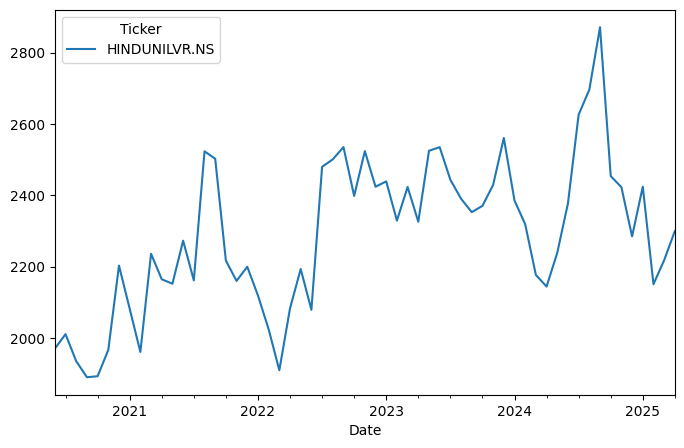

In [ ]:
hul_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
hul_df1_returns = hul_df1['Return_HINDUNILVR']
hul_df1_returns.head()

Date
2020-06-01    0.057906
2020-07-01    0.020424
2020-08-01   -0.038515
2020-09-01   -0.023463
2020-10-01    0.001474
Name: Return_HINDUNILVR, dtype: float64

In [ ]:
nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()

Date
2020-06-01    0.074038
2020-07-01    0.074248
2020-08-01    0.026798
2020-09-01   -0.014613
2020-10-01    0.039812
Name: Return_NIFTY, dtype: float64

In [ ]:
returns_hul = pd.merge(nifty_df1_returns, hul_df1_returns,how='inner',on='Date')
returns_hul.head()
returns_hul.describe()

,Return_NIFTY,Return_HINDUNILVR
count,59.000000,59.000000
mean,0.015358,0.003605
std,0.039601,0.064952
min,-0.060019,-0.157087
25%,-0.014701,-0.040707
50%,0.011225,0.001474
75%,0.038908,0.047164
max,0.108402,0.176313


####Statistical Modelling of Return_HINDUNILVR against Return_NIFTY

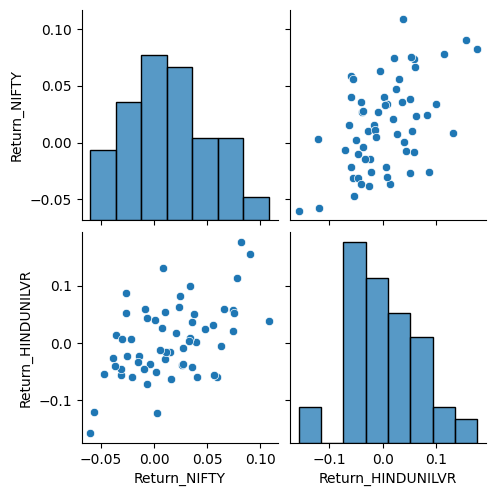

In [ ]:
sns.pairplot(returns_hul)
plt.show()

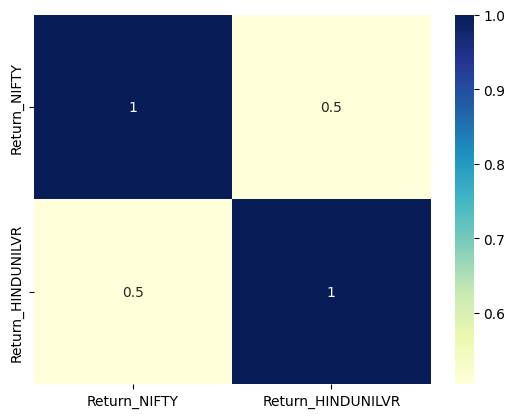

In [ ]:
sns.heatmap(returns_hul.corr(), annot = True, cmap="YlGnBu")
plt.show()

####OLS Regression of Return_HINDUNILVR against Return_NIFTY

In [ ]:
x_hul = returns_hul['Return_NIFTY']
y_hul = returns_hul['Return_HINDUNILVR']
x_sm_hul = sm.add_constant(x_hul)

#Regression - Market model
model_hul = sm.OLS(y_hul,x_sm_hul)
results_hul = model_hul.fit()

#Regression result
results_hul.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Return_HINDUNILVR   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     19.45
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           4.64e-05
Time:                        15:29:51   Log-Likelihood:                 86.758
No. Observations:                  59   AIC:                            -169.5
Df Residuals:                      57   BIC:                            -165.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0091      0.008     -1.151      0.255      -0.025       0.007
Return_NIFTY     0.8272      0.188      4.410      0.000       0.452       1.203
==============================================================================
Omnibus:                        0.925   Durbin-Watson:                   2.501
Prob(Omnibus):                  0.630   Jarque-Bera (JB):                0.938
Skew:                           0.281   Prob(JB):                        0.626
Kurtosis:                       2.742   Cond. No.                         25.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Levered Beta for HINDUNILVR = 0.7885 and is significant at 1%**

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Return_NIFTY       59 non-null     float64
 1   Return_HINDUNILVR  59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_HINDUNILVR'>

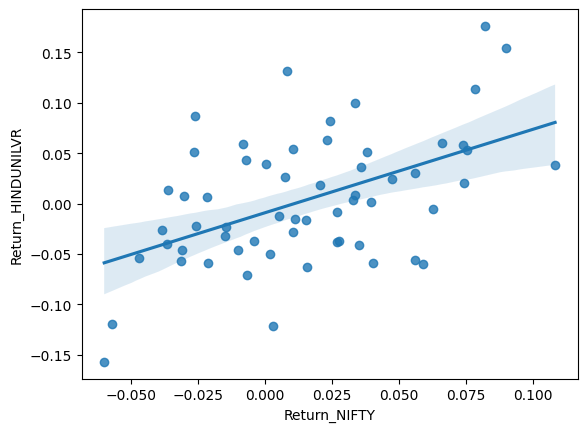

In [ ]:
#Regression - Security Characteristic line
returns_hul.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_HINDUNILVR', data = returns_hul)

In [ ]:
print('resid', results_hul.resid)

resid Date
2020-06-01    0.005761
2020-07-01   -0.031895
2020-08-01   -0.051582
2020-09-01   -0.002274
2020-10-01   -0.022360
2020-11-01   -0.042332
2020-12-01    0.057815
2021-01-01   -0.021574
2021-02-01   -0.099731
2021-03-01    0.133660
2021-04-01   -0.011165
2021-05-01   -0.048580
2021-06-01    0.055033
2021-07-01   -0.042791
2021-08-01    0.089315
2021-09-01   -0.021439
2021-10-01   -0.114730
2021-11-01    0.015006
2021-12-01    0.010257
2022-01-01   -0.024784
2022-02-01   -0.011050
2022-03-01   -0.082866
2022-04-01    0.117666
2022-05-01    0.082678
2022-06-01   -0.005605
2022-07-01    0.117286
2022-08-01   -0.010212
2022-09-01    0.052618
2022-10-01   -0.092956
2022-11-01    0.028733
2022-12-01   -0.001077
2023-01-01    0.032952
2023-02-01   -0.028797
2023-03-01    0.048406
2023-04-01   -0.061199
2023-05-01    0.071009
2023-06-01   -0.014172
2023-07-01   -0.050379
2023-08-01    0.008455
2023-09-01   -0.019398
2023-10-01    0.041455
2023-11-01   -0.005793
2023-12-01   -0.000566


count    5.900000e+01
mean    -1.176084e-18
std      5.608584e-02
min     -1.147299e-01
25%     -3.201588e-02
50%     -6.392450e-03
75%      3.720332e-02
max      1.336597e-01
dtype: float64

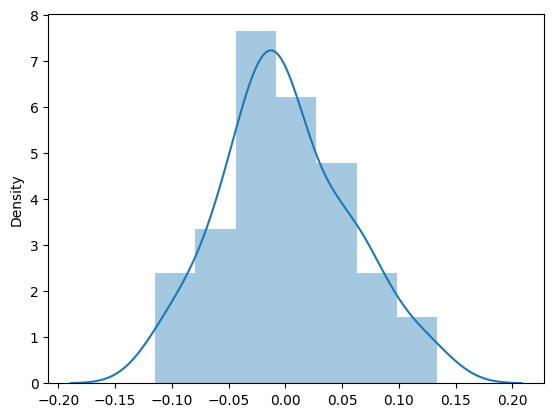

In [ ]:
#Histogram of residuals
sns.distplot(results_hul.resid)
results_hul.resid.describe()

####Unlevering the Beta for HINDUNILVR

In [ ]:
ticker = 'HINDUNILVR.NS'
firm = yf.Ticker(ticker)

debt_to_equity_hul = (firm.info['debtToEquity'])/100

print("Debt to Equity Ratio for HUL is:", debt_to_equity_hul)

beta_levered_hul = results_hul.params[1]
tax_rate = 0.2517

beta_unlevered_hul = beta_levered_hul / (1 + (debt_to_equity_hul * (1 - tax_rate)))
print("Unlevered Beta for HUL is:", beta_unlevered_hul)


Debt to Equity Ratio for HUL is: 0.03016
Unlevered Beta for HUL is: 0.8089656349312837


###Nestlé India Limited	(NSE: NESTLEIND)

####Prices of NESTLEIND and NIFTY50


In [ ]:
#Download stock prices for the security monthly data last 5 years
nestle_df = yf.download('NESTLEIND.NS',
                      start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo'
)
nestle_df.head()

Price,Close,High,Low,Open,Volume
Ticker,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS
Date,,,,,
2020-05-01,819.629028,837.565194,752.708964,837.565194,78645180
2020-06-01,802.510681,829.357722,750.071305,819.629126,69676220
2020-07-01,774.891724,833.160321,770.670721,806.915080,76714120
2020-08-01,748.034424,792.563694,744.538047,775.163792,43180040
2020-09-01,746.585083,774.553918,708.190382,750.165905,53039380


In [ ]:
#Download Market index closing prices
nifty_df = yf.download('^BSESN',start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo',
)
nifty_df.head()

Price,Close,High,Low,Open,Volume
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
Date,,,,,
2020-05-01,32424.099609,32845.480469,29968.449219,32748.140625,544100
2020-06-01,34915.800781,35706.550781,32348.099609,32906.050781,541900
2020-07-01,37606.890625,38617.031250,34927.199219,35009.589844,442900
2020-08-01,38628.289062,40010.171875,36911.230469,37595.730469,381900
2020-09-01,38067.929688,39359.511719,36495.980469,38754.000000,309800


####Log Returns of NESTLEIND and NIFTY50


In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

Date
2020-05-01         NaN
2020-06-01    0.074038
2020-07-01    0.074248
2020-08-01    0.026798
2020-09-01   -0.014613
2020-10-01    0.039812
2020-11-01    0.108402
2020-12-01    0.078420
2021-01-01   -0.031172
2021-02-01    0.059024
2021-03-01    0.008299
2021-04-01   -0.014789
2021-05-01    0.062671
2021-06-01    0.010444
2021-07-01    0.001982
2021-08-01    0.090230
2021-09-01    0.026981
2021-10-01    0.003049
2021-11-01   -0.038537
2021-12-01    0.020621
2022-01-01   -0.004122
2022-02-01   -0.030930
2022-03-01    0.040440
2022-04-01   -0.026079
2022-05-01   -0.026540
2022-06-01   -0.046930
2022-07-01    0.082357
2022-08-01    0.033593
2022-09-01   -0.036086
2022-10-01    0.056198
2022-11-01    0.038004
2022-12-01   -0.036456
2023-01-01   -0.021445
2023-02-01   -0.009919
2023-03-01    0.000498
2023-04-01    0.035322
2023-05-01    0.024405
2023-06-01    0.032928
2023-07-01    0.027570
2023-08-01   -0.025828
2023-09-01    0.015261
2023-10-01   -0.030125
2023-11-01    0.047593
2023-1

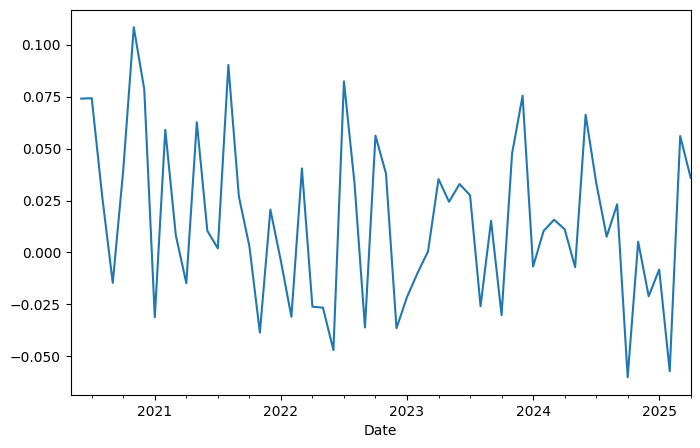

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

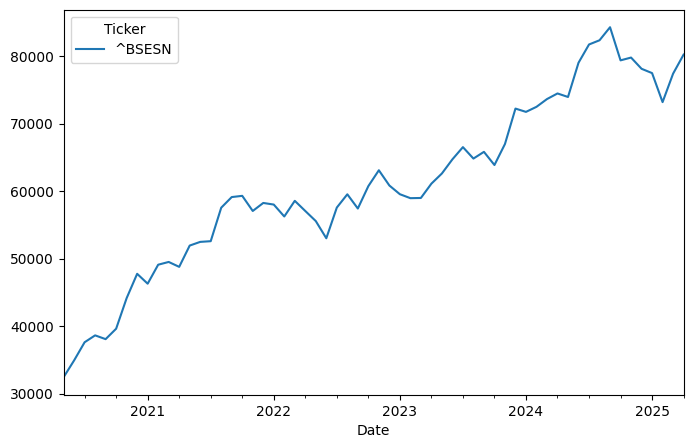

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

Price,Close,High,Low,Open,Volume,Return_NIFTY
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN,
Date,,,,,,
2020-06-01,34915.800781,35706.550781,32348.099609,32906.050781,541900,0.074038
2020-07-01,37606.890625,38617.031250,34927.199219,35009.589844,442900,0.074248
2020-08-01,38628.289062,40010.171875,36911.230469,37595.730469,381900,0.026798
2020-09-01,38067.929688,39359.511719,36495.980469,38754.000000,309800,-0.014613
2020-10-01,39614.070312,41048.050781,38410.199219,38410.199219,323000,0.039812


In [ ]:
#Ensure 'Close' column is retrieved as a Series rather than a Dataframe
close_series_nestle = nestle_df[('Close', 'NESTLEIND.NS')]
close_series_nestle = pd.to_numeric(close_series_nestle, errors='coerce')

# Step 2: Compute log returns
nestle_df[('Return_NESTLEIND', '')] = np.log(close_series_nestle / close_series_nestle.shift(1))

# Step 3: Drop NaNs in return column
nestle_df.dropna(subset=[('Return_NESTLEIND', '')], inplace=True)

print(nestle_df['Return_NESTLEIND'])

Date
2020-06-01   -0.021107
2020-07-01   -0.035022
2020-08-01   -0.035274
2020-09-01   -0.001939
2020-10-01    0.075183
2020-11-01    0.049426
2020-12-01    0.027638
2021-01-01   -0.075084
2021-02-01   -0.057818
2021-03-01    0.063966
2021-04-01   -0.051152
2021-05-01    0.087006
2021-06-01   -0.003541
2021-07-01    0.003942
2021-08-01    0.095045
2021-09-01   -0.001141
2021-10-01   -0.023171
2021-11-01    0.013890
2021-12-01    0.028472
2022-01-01   -0.061973
2022-02-01   -0.048814
2022-03-01   -0.014769
2022-04-01    0.053204
2022-05-01   -0.030542
2022-06-01   -0.012599
2022-07-01    0.102677
2022-08-01    0.028855
2022-09-01   -0.039987
2022-10-01    0.061708
2022-11-01   -0.002922
2022-12-01   -0.029047
2023-01-01   -0.030463
2023-02-01   -0.018455
2023-03-01    0.053929
2023-04-01    0.099291
2023-05-01    0.000929
2023-06-01    0.054816
2023-07-01   -0.015006
2023-08-01   -0.025457
2023-09-01    0.023398
2023-10-01    0.073968
2023-11-01    0.000056
2023-12-01    0.098119
2024-0

In [ ]:
nestle_df1 = nestle_df.dropna(axis=0)
nestle_df1.head()

Price,Close,High,Low,Open,Volume,Return_NESTLEIND
Ticker,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,
Date,,,,,,
2020-06-01,802.510681,829.357722,750.071305,819.629126,69676220,-0.021107
2020-07-01,774.891724,833.160321,770.670721,806.915080,76714120,-0.035022
2020-08-01,748.034424,792.563694,744.538047,775.163792,43180040,-0.035274
2020-09-01,746.585083,774.553918,708.190382,750.165905,53039380,-0.001939
2020-10-01,804.879700,814.184651,721.088077,746.601709,58943660,0.075183


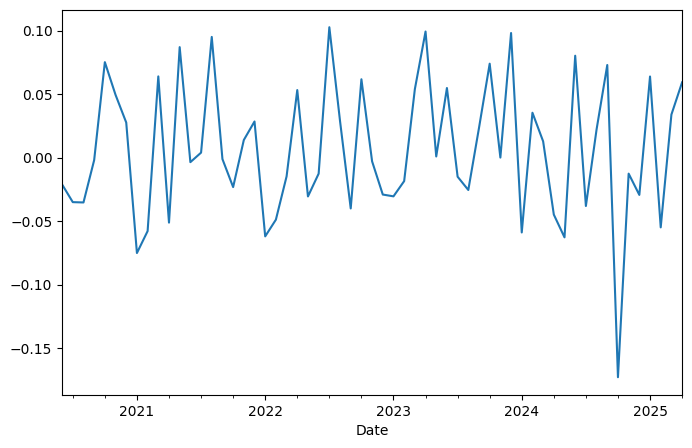

In [ ]:
nestle_df['Return_NESTLEIND'].plot(figsize=(8,5))
plt.show()

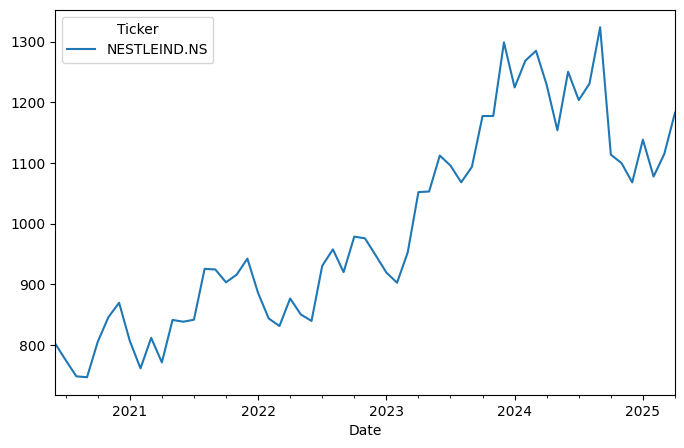

In [ ]:
nestle_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nestle_df1_returns = nestle_df1['Return_NESTLEIND']
nestle_df1_returns.head()

Date
2020-06-01   -0.021107
2020-07-01   -0.035022
2020-08-01   -0.035274
2020-09-01   -0.001939
2020-10-01    0.075183
Name: Return_NESTLEIND, dtype: float64

In [ ]:
nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()

Date
2020-06-01    0.074038
2020-07-01    0.074248
2020-08-01    0.026798
2020-09-01   -0.014613
2020-10-01    0.039812
Name: Return_NIFTY, dtype: float64

In [ ]:
returns_nestle = pd.merge(nifty_df1_returns, nestle_df1_returns,how='inner',on='Date')
returns_nestle.head()
returns_nestle.describe()

,Return_NIFTY,Return_NESTLEIND
count,59.000000,59.000000
mean,0.015358,0.006216
std,0.039601,0.054473
min,-0.060019,-0.172853
25%,-0.014701,-0.030503
50%,0.011225,-0.001141
75%,0.038908,0.053566
max,0.108402,0.102677


####Statistical Modelling of Return_NESTLEIND against Return_NIFTY

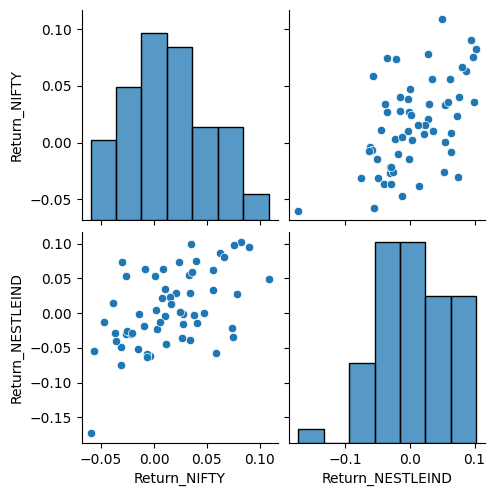

In [ ]:
sns.pairplot(returns_nestle)
plt.show()

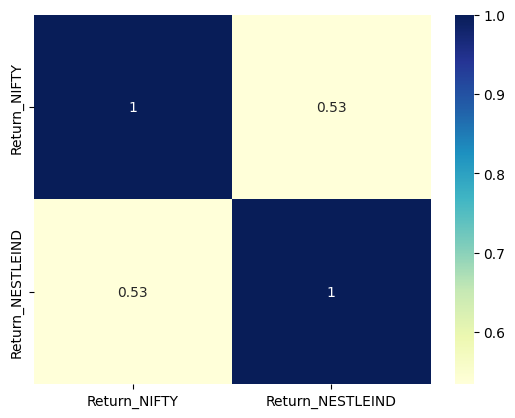

In [ ]:
sns.heatmap(returns_nestle.corr(), annot = True, cmap="YlGnBu")
plt.show()

####OLS Regression of Return_NESTLEIND against Return_NIFTY

In [ ]:
x_nestle = returns_nestle['Return_NIFTY']
y_nestle = returns_nestle['Return_NESTLEIND']
x_sm_nestle = sm.add_constant(x_nestle)

#Regression - Market model
model_nestle = sm.OLS(y_nestle,x_sm_nestle)
results_nestle = model_nestle.fit()

#Regression result
results_nestle.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Return_NESTLEIND   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     22.71
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.34e-05
Time:                        15:29:57   Log-Likelihood:                 98.373
No. Observations:                  59   AIC:                            -192.7
Df Residuals:                      57   BIC:                            -188.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0051      0.006     -0.779      0.439      -0.018       0.008
Return_NIFTY     0.7343      0.154      4.766      0.000       0.426       1.043
==============================================================================
Omnibus:                        0.404   Durbin-Watson:                   2.123
Prob(Omnibus):                  0.817   Jarque-Bera (JB):                0.350
Skew:                          -0.179   Prob(JB):                        0.839
Kurtosis:                       2.878   Cond. No.                         25.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Levered Beta for NESTLEIND = 0.6899 and is significant at 1%**

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Return_NIFTY      59 non-null     float64
 1   Return_NESTLEIND  59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_NESTLEIND'>

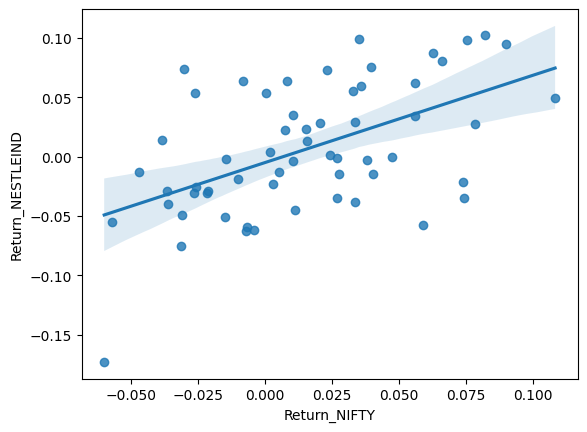

In [ ]:
#Regression - Security Characteristic line
returns_nestle.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_NESTLEIND', data = returns_nestle)

In [ ]:
print('resid', results_nestle.resid)

In [ ]:
#Histogram of residuals
sns.distplot(results_nestle.resid)
results_nestle.resid.describe()

####Unlevering the Beta for NESTLEIND

In [ ]:
ticker = 'NESTLEIND.NS'
firm = yf.Ticker(ticker)

debt_to_equity_nestle = (firm.info['debtToEquity'])/100

print("Debt to Equity Ratio for NESTLE is:", debt_to_equity_nestle)

beta_levered_nestle = results_nestle.params[1]
tax_rate = 0.2517

beta_unlevered_nestle = beta_levered_nestle / (1 + (debt_to_equity_nestle * (1 - tax_rate)))
print("Unlevered Beta for NESTLE is:", beta_unlevered_nestle)


###Dabur India Limited	(NSE: DABUR)

####Prices of DABUR and NIFTY50

In [ ]:
#Download stock prices for the security monthly data last 5 years
dabur_df = yf.download('DABUR.NS',
                      start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo'
)
dabur_df.head()

In [ ]:
#Download Market index closing prices
nifty_df = yf.download('^BSESN',start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo',
)
nifty_df.head()

####Log Returns of DABUR and NIFTY50

In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

In [ ]:
#Ensure 'Close' column is retrieved as a Series rather than a Dataframe
close_series_dabur = dabur_df[('Close', 'DABUR.NS')]
close_series_dabur = pd.to_numeric(close_series_dabur, errors='coerce')

# Step 2: Compute log returns
dabur_df[('Return_DABUR', '')] = np.log(close_series_dabur / close_series_dabur.shift(1))

# Step 3: Drop NaNs in return column
dabur_df.dropna(subset=[('Return_DABUR', '')], inplace=True)

print(dabur_df['Return_DABUR'])


In [ ]:
dabur_df1 = dabur_df.dropna(axis=0)
dabur_df1.head()

In [ ]:
dabur_df['Return_DABUR'].plot(figsize=(8,5))
plt.show()

In [ ]:
dabur_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
dabur_df1_returns = dabur_df1['Return_DABUR']
dabur_df1_returns.head()

In [ ]:
nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()

In [ ]:
returns_dabur = pd.merge(nifty_df1_returns, dabur_df1_returns,how='inner',on='Date')
returns_dabur.head()
returns_dabur.describe()

####Statistical Modelling of Return_DABUR against Return_NIFTY

In [ ]:
sns.pairplot(returns_dabur)
plt.show()

In [ ]:
sns.heatmap(returns_dabur.corr(), annot = True, cmap="YlGnBu")
plt.show()

####OLS Regression of Return_DABUR against Return_NIFTY

In [ ]:
x_dabur = returns_dabur['Return_NIFTY']
y_dabur = returns_dabur['Return_DABUR']
x_sm_dabur = sm.add_constant(x_dabur)

#Regression - Market model
model_dabur = sm.OLS(y_dabur,x_sm_dabur)
results_dabur = model_dabur.fit()

#Regression result
results_dabur.summary()

**Levered Beta for DABUR = 0.6302 and is significant at 1%**

In [ ]:
#Regression - Security Characteristic line
returns_dabur.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_DABUR', data = returns_dabur)

In [ ]:
print('resid', results_dabur.resid)

In [ ]:
#Histogram of residuals
sns.distplot(results_dabur.resid)
results_dabur.resid.describe()

####Unlevering the Beta for DABUR

In [ ]:
ticker = 'DABUR.NS'
firm = yf.Ticker(ticker)

debt_to_equity_dabur = (firm.info['debtToEquity'])/100

print("Debt to Equity Ratio for DABUR is:", debt_to_equity_dabur)

beta_levered_dabur = results_dabur.params[1]
tax_rate = 0.2517

beta_unlevered_dabur = beta_levered_dabur / (1 + (debt_to_equity_dabur * (1 - tax_rate)))
print("Unevered Beta for DABUR is:", beta_unlevered_dabur)

###ITC Limited (NSE: ITC)

####Prices of ITC and NIFTY50

In [ ]:
#Download stock prices for the security monthly data last 5 years
itc_df = yf.download('ITC.NS',
                      start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo'
)
itc_df.head()

In [ ]:
#Download Market index closing prices
nifty_df = yf.download('^BSESN',start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo',
)
nifty_df.head()

####Log Returns of ITC and NIFTY50


In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

In [ ]:

#Ensure 'Close' column is retrieved as a Series rather than a Dataframe
close_series_itc = itc_df[('Close', 'ITC.NS')]
close_series_itc = pd.to_numeric(close_series_itc, errors='coerce')

# Step 2: Compute log returns
itc_df[('Return_ITC', '')] = np.log(close_series_itc / close_series_itc.shift(1))

# Step 3: Drop NaNs in return column
itc_df.dropna(subset=[('Return_ITC', '')], inplace=True)

print(itc_df['Return_ITC'])


In [ ]:
itc_df1 = itc_df.dropna(axis=0)
itc_df1.head()

In [ ]:
itc_df['Return_ITC'].plot(figsize=(8,5))
plt.show()

In [ ]:
itc_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
itc_df1_returns = itc_df1['Return_ITC']
itc_df1_returns.head()

In [ ]:
nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()

In [ ]:
returns_itc = pd.merge(nifty_df1_returns, itc_df1_returns,how='inner',on='Date')
returns_itc.head()
returns_itc.describe()

####Statistical Modelling of Return_ITC against Return_NIFTY

In [ ]:
sns.pairplot(returns_itc)
plt.show()

In [ ]:
sns.heatmap(returns_itc.corr(), annot = True, cmap="YlGnBu")
plt.show()

####OLS Regression of Return_ITC against Return_NIFTY

In [ ]:
x_itc = returns_itc['Return_NIFTY']
y_itc = returns_itc['Return_ITC']
x_sm_itc = sm.add_constant(x_itc)

#Regression - Market model
model_itc = sm.OLS(y_itc,x_sm_itc)
results_itc = model_itc.fit()

#Regression result
results_itc.summary()


**Levered Beta for ITC = 0.7510 and is significant at 1%**

In [ ]:
#Regression - Security Characteristic line
returns_itc.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_ITC', data = returns_itc)

In [ ]:
print('resid', results_itc.resid)

In [ ]:
#Histogram of residuals
sns.distplot(results_itc.resid)
results_itc.resid.describe()

####Unlevering the Beta for ITC

In [ ]:
ticker = 'ITC.NS'
firm = yf.Ticker(ticker)

debt_to_equity_itc = (firm.info['debtToEquity'])/100

print("Debt to Equity Ratio for ITC:", debt_to_equity_itc)

beta_levered_itc = results_itc.params[1]
tax_rate = 0.2517

beta_unlevered_itc = beta_levered_itc / (1 + (debt_to_equity_itc * (1 - tax_rate)))
print("Unlevered Beta for ITC:", beta_unlevered_itc)

###Tata Consumer Products Limited	(NSE: TATACONSUM)

####Prices of TATACONSUM and NIFTY50

In [ ]:
#Download stock prices for the security monthly data last 5 years
tataconsum_df = yf.download('TATACONSUM.NS',
                      start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo'
)
tataconsum_df.head()

In [ ]:
#Download Market index closing prices
nifty_df = yf.download('^BSESN',start='2020-04-02',
                      end='2025-04-02',
                      progress=False,interval ='1mo',
)
nifty_df.head()

####Log Returns of TATACONSUM and NIFTY50


In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

In [ ]:
#Ensure 'Close' column is retrieved as a Series rather than a Dataframe
close_series_tataconsum = tataconsum_df[('Close','TATACONSUM.NS')]
close_series_tataconsum = pd.to_numeric(close_series_tataconsum, errors='coerce')

# Step 2: Compute log returns
tataconsum_df[('Return_TATACONSUM', '')] = np.log(close_series_tataconsum / close_series_tataconsum.shift(1))

# Step 3: Drop NaNs in return column
tataconsum_df.dropna(subset=[('Return_TATACONSUM', '')], inplace=True)

print(tataconsum_df['Return_TATACONSUM'])


In [ ]:
tataconsum_df1 = tataconsum_df.dropna(axis=0)
tataconsum_df1.head()

In [ ]:
tataconsum_df['Return_TATACONSUM'].plot(figsize=(8,5))
plt.show()


In [ ]:
tataconsum_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
tataconsum_df1_returns = tataconsum_df1['Return_TATACONSUM']
tataconsum_df1_returns.head()

In [ ]:
nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()

In [ ]:
returns_tataconsum = pd.merge(nifty_df1_returns, tataconsum_df1_returns,how='inner',on='Date')
returns_tataconsum.head()
returns_tataconsum.describe()

####Statistical Modelling of Return_TATACONSUM against Return_NIFTY

In [ ]:
sns.pairplot(returns_tataconsum)
plt.show()

In [ ]:
sns.heatmap(returns_tataconsum.corr(), annot = True, cmap="YlGnBu")
plt.show()

####OLS Regression of Return_TATACONSUM against Return_NIFTY

In [ ]:
x_tataconsum = returns_tataconsum['Return_NIFTY']
y_tataconsum = returns_tataconsum['Return_TATACONSUM']
x_sm_tataconsum = sm.add_constant(x_tataconsum)

#Regression - Market model
model_tataconsum = sm.OLS(y_tataconsum,x_sm_tataconsum)
results_tataconsum = model_tataconsum.fit()

#Regression result
results_tataconsum.summary()

**Levered Beta for TATACONSUM = 1.0718 and is significant at 1%**

In [ ]:
#Regression - Security Characteristic line
returns_tataconsum.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_TATACONSUM', data = returns_tataconsum)

In [ ]:
print('resid', results_tataconsum.resid)

In [ ]:
#Histogram of residuals
sns.distplot(results_tataconsum.resid)
results_tataconsum.resid.describe()

####Unlevering the Beta for TATACONSUM

In [ ]:
ticker = 'TATACONSUM.NS'
firm = yf.Ticker(ticker)

debt_to_equity_tataconsum = (firm.info['debtToEquity'])/100

print("Debt to Equity Ratio for TATA CONSUMER:", debt_to_equity_tataconsum)

beta_levered_tataconsum = results_tataconsum.params[1]
tax_rate = 0.2517

beta_unlevered_tataconsum = beta_levered_tataconsum / (1 + (debt_to_equity_tataconsum * (1 - tax_rate)))
print("Unlevered Beta for TATA CONSUMER:", beta_unlevered_tataconsum)

##Average of Unlevered Betas

In [ ]:
avg_unlevered_beta = (beta_unlevered_hul + beta_unlevered_nestle + beta_unlevered_dabur + beta_unlevered_itc + beta_unlevered_tataconsum)/5
print("Average of Unlevered Betas:", avg_unlevered_beta)


##Market Value of D/E for BRITANNIA

In [ ]:
ticker_symbol = 'BRITANNIA.NS'
brit = yf.Ticker(ticker_symbol)

balance_sheet = brit.balance_sheet


balance_sheet_df = balance_sheet.reset_index()


total_debt = balance_sheet_df.loc[balance_sheet_df['index'] == 'Total Debt'].values[0][1]
tangible_book_value = balance_sheet_df.loc[balance_sheet_df['index'] == 'Tangible Book Value'].values[0][1]


debt_to_equity_brit = total_debt / tangible_book_value
print("Debt to Equity Ratio for BRITANNIA:", debt_to_equity_brit)

##Relevering the Beta for Britannia

In [ ]:
beta_levered_brit_bottom_up = avg_unlevered_beta*(1+(1-tax_rate)*debt_to_equity_brit)
print("Levered Beta for Britannia Industries:", beta_levered_brit_bottom_up)

##CAPM Model

The CAPM (Capital Asset Pricing Model) is represented by the following equation:

$$
E(r_s) = r_f + \beta (E(r_m) - r_f)
$$

Where:
- E($r_s$) is the expected return on the investment (Cost of Equity).
- E($r_m$) is the expected return of the market.
- $r_f$ is the risk-free rate.
- $\beta$ is the beta, which measures the sensitivity of the investment's returns to market returns.

This equation helps in estimating the expected return on an investment based on its risk, market conditions, and the risk-free rate.

Cost of equity capital for **BRITANNIA** (Bottom-Up Approach)

In [ ]:
Expected_market_return_bottom_up=nifty_df['Return_NIFTY'].mean() *12
print("Expected Market Return:", Expected_market_return_bottom_up)
Risk_free_rate = 0.06805642
Cost_of_equity_bottom_up = Risk_free_rate + (beta_levered_brit_bottom_up * (Expected_market_return_bottom_up - Risk_free_rate))
print("The Cost of Equity for Britannia Industries using the Bottom-Up approach:", Cost_of_equity_bottom_up)

#Cost of Debt

The **cost of debt** is the effective interest rate a company pays on its borrowings. It compensates lenders for both the time value of money and the credit risk associated with the borrower.

$$
\text{Cost of Debt} = r_f + CDS
$$

Where:  
- $R_f$: Risk-free rate  
- $CDS$: Credit Default Spread

We will now calculate The Cost of Debt for Britannia Industries

## Interest Coverage Ratio

In [ ]:
ticker_symbol = "BRITANNIA.NS"
company = yf.Ticker(ticker_symbol)


income_statement = company.financials


ebit = income_statement.loc["EBIT"]
interest_expense = income_statement.loc["Interest Expense"]


interest_coverage_ratio = ebit / interest_expense

print("Interest Coverage Ratio  for", ticker_symbol, "is", interest_coverage_ratio.iloc[0])


##Credit Default Spread

###Types of Comapnies based on Market Capitalizaton
1. **Large Cap:** The Market Cap of these companies is significantly high, coming in at around Rs. 20,000 crores or more.
2. **Mid Cap:** The Market Cap generally tends to range from Rs. 5,000 to Rs. 20,000 crores.
3. **Small Cap:** The Market Cap is generally below Rs. 5,000 crores

| Interest Cov Ratio (ICR) |  Stock Rating | Spread   |
|-------------------------|--------|----------|
| > 8.5                   | AAA    | 0.75%    |*italicized text*
| 6.5 - 8.5              | AA     | 1.00%    |
| 5.5 - 6.5              | A+     | 1.50%    |
| 4.25 - 5.5             | A      | 1.80%    |
| 3 - 4.25               | A-     | 2.00%    |
| 2.5 - 3                | BBB    | 2.25%    |
| 2 - 2.5                | BB     | 3.50%    |*italicized text*
| 1.75 - 2               | B+     | 4.75%    |
| 1.5 - 1.75             | B      | 6.50%    |
| 1.25 - 1.5            | B-     | 8.00%    |
| 0.8 - 1.25             | CCC    | 10.00%   |
| 0.65 - 0.8            | CC     | 11.50%   |
| 0.2 - 0.65             | C      | 12.70%   |
| < 0.2                  | D      | 14.00%   |


The Market Cap of BRITANNIA is 120,997 Crores (2025) which is greater than 20000 Crores thus BRITANNIA is a Large Cap company.

Also, its Interest Coverage Ratio is 18.96885407672382, therefore, its Credit Default Spread is 0.75%

In [ ]:
cost_of_debt_credit_default_spread = Risk_free_rate + (0.75/100)
print("The Cost of Debt for Britannia using the Credit Default Spread Approach is", cost_of_debt_credit_default_spread)

#Market Value of Debt and Market Value of Equity

In [ ]:

ticker_symbol = 'BRITANNIA.NS'
brit = yf.Ticker(ticker_symbol)

balance_sheet = brit.balance_sheet


balance_sheet_df = balance_sheet.reset_index()


total_debt = balance_sheet_df.loc[balance_sheet_df['index'] == 'Total Debt'].values[0][1]

market_value_of_debt = total_debt
print("Market Value of Debt for", ticker_symbol,"is", market_value_of_debt)

mve_brit = company.info['marketCap']
print("Market Value of Equity for", ticker_symbol,"is", mve_brit)

#Weighted Average Cost of Capital (Top-Down Approach)
**Weighted Average Cost of Capital (WACC)** is the average return a company must earn on its existing assets to satisfy both equity and debt holders.

$$
\text{WACC} = \left( \frac{\text{MVE}}{\text{MVE} + \text{MVD}} \times r_e \right) + \left( \frac{\text{MVD}}{\text{MVE} + \text{MVD}} \times r_d \times (1 - T) \right)
$$

**Where:**  
- $r_e$: Cost of equity (Top-Down Approach)
- $r_d$: Cost of debt  
- $T$: Corporate tax rate  
- MVE: Market value of equity  
- MVD: Market value of debt

In [ ]:
print("Cost of Equity :", Cost_of_equity_top_down)
print("Cost of Debt :", cost_of_debt_credit_default_spread)
print("Market Value of Equity :", mve_brit)
print("Market Value of Debt :", market_value_of_debt)
print("Tax Rate:", tax_rate)

R_wacc_top_down = (Cost_of_equity_top_down * (mve_brit/(mve_brit+market_value_of_debt))) + (cost_of_debt_credit_default_spread * (1-tax_rate) * (market_value_of_debt/(mve_brit+market_value_of_debt)))
print("Weighted Average Cost of Capital for BRITANNIA using Top-Down Approach is", R_wacc_top_down)

Thus, Weighted Average Cost of Capital for Britannia Industries using Top-Down Approach is **0.1396 = 13.96%**


#Weighted Average Cost of Capital (Bottom-Up Approach)
**Weighted Average Cost of Capital (WACC)** is the average return a company must earn on its existing assets to satisfy both equity and debt holders.

$$
\text{WACC} = \left( \frac{\text{MVE}}{\text{MVE} + \text{MVD}} \times r_e \right) + \left( \frac{\text{MVD}}{\text{MVE} + \text{MVD}} \times r_d \times (1 - T) \right)
$$

**Where:**  
- $r_e$: Cost of equity (Bottom-Up Approach)
- $r_d$: Cost of debt  
- $T$: Corporate tax rate  
- MVE: Market value of equity  
- MVD: Market value of debt

In [ ]:
print("Cost of Equity(Bottom-Up):", Cost_of_equity_bottom_up)
print("Cost of Debt:", cost_of_debt_credit_default_spread)
print("Market Value of Equity:", mve_brit)
print("Market Value of Debt:", market_value_of_debt)
print("Tax Rate:", tax_rate)

R_wacc_bottom_up = (Cost_of_equity_bottom_up * (mve_brit/(mve_brit+market_value_of_debt))) + (cost_of_debt_credit_default_spread * (1-tax_rate) * (market_value_of_debt/(mve_brit+market_value_of_debt)))
print("Weighted Average Cost of Capital for BRITANNIA using Bottom-Up Approach is", R_wacc_bottom_up)

Thus, Weighted Average Cost of Capital for Britannia Industries using Bottom-Up Approach is **0.1732 = 17.32%**
